# Task 1: Sentiment Analysis on Product Reviews
Classify reviews as **Positive** or **Negative** using TF-IDF + Logistic Regression.

In [4]:
# Install required libraries
!pip install pandas scikit-learn nltk

In [5]:
import pandas as pd
import nltk
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to C:\Users\ADAM-
[nltk_data]     LAP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Load Dataset
Using IMDb dataset from Kaggle. Make sure `IMDB Dataset.csv` is in the same folder.

In [ ]:
df = pd.read_csv('IMDB Dataset.csv')
print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


## 2. Text Preprocessing

In [7]:
def clean_text(text):
    # Remove HTML tags (common in IMDb reviews)
    text = re.sub(r'<.*?>', '', text)
    # Keep only letters, remove numbers and punctuation
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Lowercase and split into words
    words = text.lower().split()
    # Remove stopwords (e.g. 'the', 'is', 'a')
    words = [w for w in words if w not in STOPWORDS]
    return ' '.join(words)

df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review']].head(2)

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...


## 3. Encode Labels

In [8]:
# Convert 'positive' -> 1,  'negative' -> 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(df['label'].value_counts())

label
1    25000
0    25000
Name: count, dtype: int64


## 4. Train - Test Split

In [ ]:
X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 40000 | Test: 10000


## 5. TF-IDF Vectorization

In [10]:
# Convert text to numbers using TF-IDF (top 10,000 words)
tfidf = TfidfVectorizer(max_features=10000)
X_train_vec = tfidf.fit_transform(X_train)   # learn vocab + transform
X_test_vec  = tfidf.transform(X_test)         # transform only (no refit)

## 6. Train & Evaluate — Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

y_pred_lr = lr.predict(X_test_vec)

print(' Logistic Regression ')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Negative','Positive']))

=== Logistic Regression ===
Accuracy : 0.8951
              precision    recall  f1-score   support

    Negative       0.91      0.88      0.89      4961
    Positive       0.88      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.89      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## 7. Bonus — Naive Bayes Comparison

In [12]:
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

y_pred_nb = nb.predict(X_test_vec)

print('=== Naive Bayes ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}')
print(classification_report(y_test, y_pred_nb, target_names=['Negative','Positive']))

print(f"\nLR  Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"NB  Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")

=== Naive Bayes ===
Accuracy : 0.8600
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      4961
    Positive       0.86      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


LR  Accuracy: 0.8951
NB  Accuracy: 0.8600


## 8. Bonus — Most Frequent Positive & Negative Words

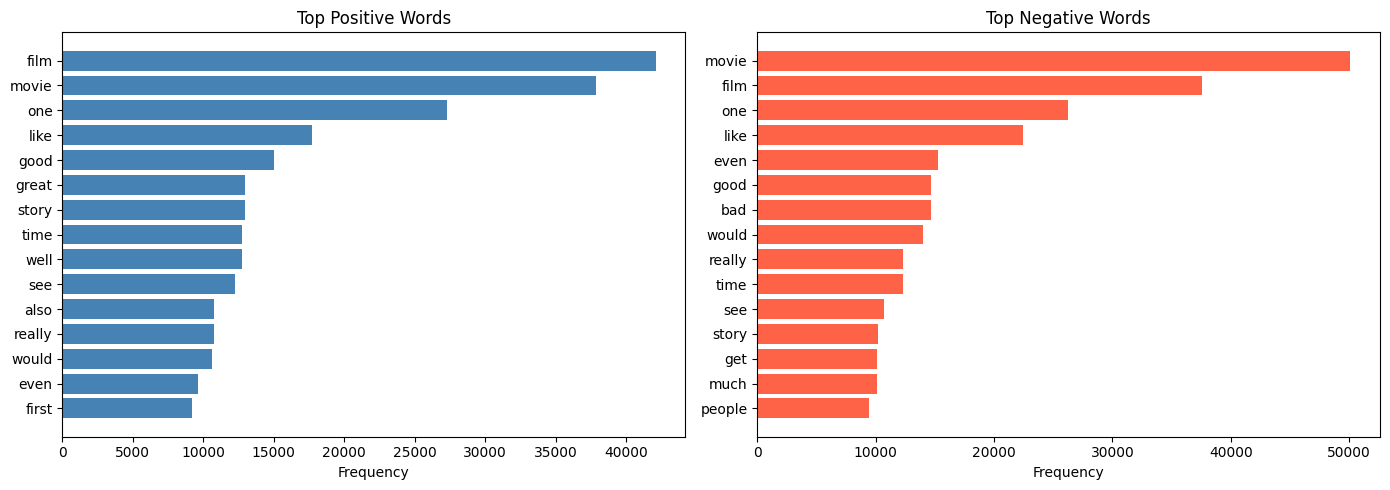

In [13]:
import matplotlib.pyplot as plt
from collections import Counter

def top_words(label_value, n=15):
    # Join all reviews with the given label into one string
    text = ' '.join(df[df['label'] == label_value]['clean_review'])
    # Count word frequencies and return top n
    return Counter(text.split()).most_common(n)

pos_words = top_words(1)
neg_words = top_words(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, words, title, color in zip(
    axes,
    [pos_words, neg_words],
    ['Top Positive Words', 'Top Negative Words'],
    ['steelblue', 'tomato']
):
    labels, counts = zip(*words)
    ax.barh(labels[::-1], counts[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## 9. Predict a Custom Review

In [14]:
def predict_review(text):
    # Clean → vectorize → predict using Logistic Regression
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = lr.predict(vec)[0]
    return 'Positive' if pred == 1 else 'Negative'

print(predict_review("This movie was absolutely amazing and very enjoyable!"))
print(predict_review("Terrible film. Waste of time and money."))

Positive
Negative
